In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

plt.style.use("dark_background")

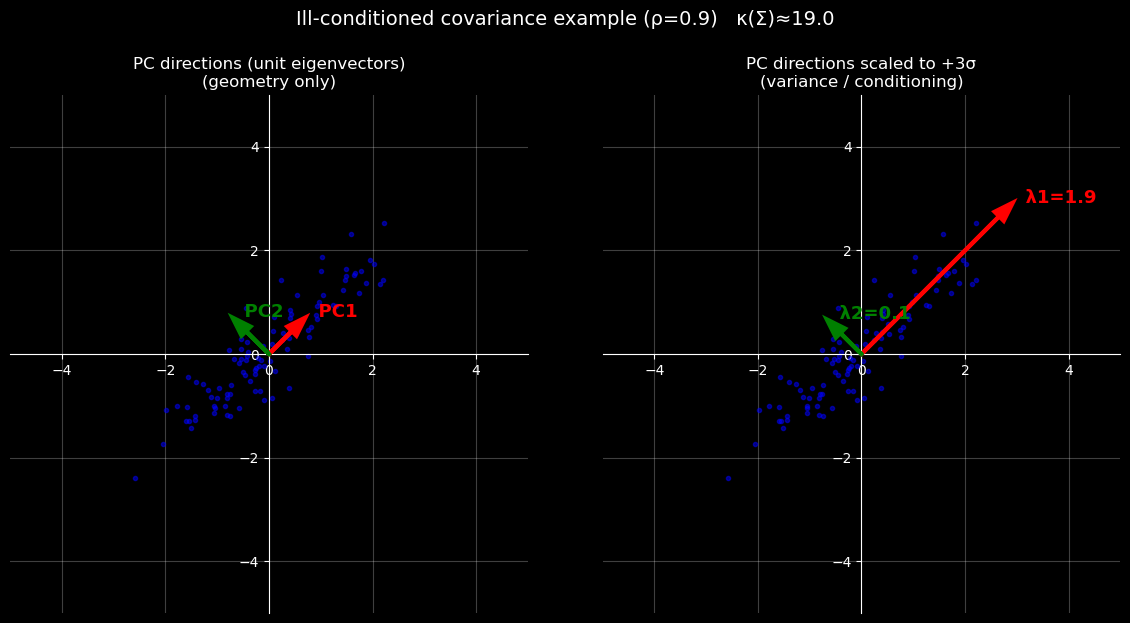

Covariance matrix (true):
[[1.  0.9]
 [0.9 1. ]]


Eigenvalues (largest -> smallest):
[1.9 0.1]

Eigenvectors (columns):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Condition number κ(Σ) = λ_max / λ_min = 19.000000000000014


In [12]:
# -----------------------------
# User-defined parameters
# -----------------------------
sigma_x = 1.0   # std of x
sigma_y = 1.0   # std of y
rho     = 0.9  # Pearson correlation (-1 to 1)

# -----------------------------
# Construct covariance matrix (true)
# -----------------------------
cov_true = np.array([
    [sigma_x**2,             rho * sigma_x * sigma_y],
    [rho * sigma_x * sigma_y,      sigma_y**2]
], dtype=float)

# -----------------------------
# Sample from N(0, cov_true)
# -----------------------------
n_samp = 100
df = pd.DataFrame(
    np.random.multivariate_normal(
        mean=[0.0, 0.0],
        cov=cov_true,
        size=n_samp
    ),
    columns=["x", "y"]
)

# -----------------------------
# Eigen-decomposition of covariance (THEORETICAL)
# -----------------------------
from numpy import linalg as LA

w, v = LA.eigh(cov_true)            # symmetric -> real eigenpairs, orthonormal eigenvectors
idx = np.argsort(w)[::-1]           # sort largest -> smallest
w = w[idx]
v = v[:, idx]

cond_cov = np.abs(w).max() / np.abs(w).min()

# -----------------------------
# Side-by-side visualization:
# left = unit eigenvectors, right = +3σ scaled
# -----------------------------
p = np.array([-3.0, 0.0])  # optional reference point

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

titles = [
    "PC directions (unit eigenvectors)\n(geometry only)",
    "PC directions scaled to +3σ\n(variance / conditioning)"
]

scales = [
    1.0,                 # unit eigenvectors
    3.0 * np.sqrt(w)     # +3σ scaling along each PC
]

for ax, title, scale in zip(axes, titles, scales):

    # Data cloud
    ax.plot(df.x.values, df.y.values, "b.", alpha=0.5)

    # Centered axes spines at (0,0)
    ax.spines["left"].set_position("zero")
    ax.spines["bottom"].set_position("zero")
    ax.spines["right"].set_color("none")
    ax.spines["top"].set_color("none")
    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

    # Draw PC axes (positive direction only)
    for k, color in [(0, "red"), (1, "green")]:
        vec = v[:, k]
        length = scale if np.isscalar(scale) else scale[k]
        dx, dy = length * vec[0], length * vec[1]

        ax.arrow(
            0, 0, dx, dy,
            head_width=0.25,
            length_includes_head=True,
            linewidth=3,
            color=color,
            zorder=5
        )

        label = f"PC{k+1}" if np.isscalar(scale) else f"λ{k+1}={w[k]:.3g}"
        ax.text(dx, dy, f"  {label}", fontsize=13, color=color, weight="bold", zorder=6)
    
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.grid(True, alpha=0.25)

fig.suptitle(
    f"Ill-conditioned covariance example (ρ={rho})   κ(Σ)≈{cond_cov:.1f}",
    fontsize=14,
    y=1.03
)

plt.tight_layout()
plt.show()

print("Covariance matrix (true):")
print(cov_true)
print()
print("\nEigenvalues (largest -> smallest):")
print(w)
print()
print("Eigenvectors (columns):")
print(v)
print()
print("Condition number κ(Σ) = λ_max / λ_min =", cond_cov)

X^T X:
[[100.           0.18027913   9.23249132]
 [  0.18027913 117.75222839  97.83816042]
 [  9.23249132  97.83816042 100.04785251]]
Eigenvalues of X^T X: [207.5149143 100.1229429  10.1622237]
Condition number κ(X^T X): 20.42022695123658

True coefficients: [1. 1. 1.]
OLS coefficients:  [1.00336204 0.99301067 1.00171733]

MAE: 0.03868843209631136
MSE: 0.002292741153910032


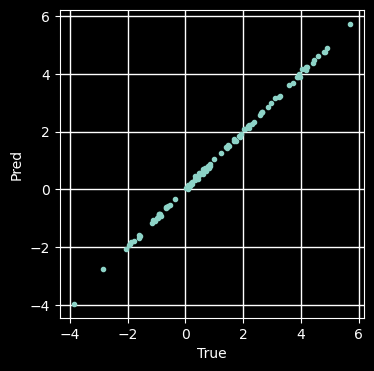

In [13]:
# ============================================================
# Ill-conditioned regression example
# z = b0 + b1 x + b2 y + eps
# ============================================================

# -----------------------------
# Generate response
# -----------------------------
b_true = np.array([1.0, 1.0, 1.0])   # [b0, b1, b2]
noise_std = 0.05

X = np.column_stack([
    np.ones(len(df)),
    df["x"].values,
    df["y"].values
])

z = X @ b_true + noise_std * np.random.randn(len(df))

# -----------------------------
# Normal equations
# -----------------------------
XtX = X.T @ X
Xtz = X.T @ z

# Eigen-decomposition of XtX
w_reg, v_reg = LA.eigh(XtX)
idx = np.argsort(w_reg)[::-1]
w_reg = w_reg[idx]
v_reg = v_reg[:, idx]

cond_XtX = w_reg.max() / w_reg.min()

print("X^T X:")
print(XtX)
print("Eigenvalues of X^T X:", w_reg)
print("Condition number κ(X^T X):", cond_XtX)
print()

# -----------------------------
# OLS solution
# -----------------------------
b_hat = LA.solve(XtX, Xtz)

print("True coefficients:", b_true)
print("OLS coefficients: ", b_hat)
print()

# -----------------------------
# Predictions and error metrics
# -----------------------------
z_hat = X @ b_hat

mae = np.mean(np.abs(z - z_hat))
mse = np.mean((z - z_hat)**2)

print("MAE:", mae)
print("MSE:", mse)

plt.figure(figsize=(4,4))
plt.plot(z, z_hat, '.')
plt.xlabel("True")
plt.ylabel("Pred")
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linewidth=1)
plt.show()